# 🚗 Tesla EV Deliveries & Production — End-to-End ML Pipeline (2015–2025)

**Dataset:** Tesla Worldwide Sales, Production, and Performance Dataset (Kaggle)  
**Objective:** Full ML pipeline covering Preprocessing → EDA → Feature Engineering → Regression Modeling → Hyperparameter Tuning → Time Series Forecasting

---
## Table of Contents
1. [Setup & Data Loading](#1)
2. [Preprocessing & Data Cleaning](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Feature Engineering](#4)
5. [Regression Modeling](#5)
6. [Hyperparameter Tuning](#6)
7. [Time Series Forecasting](#7)
8. [Key Insights & Conclusions](#8)


## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#378ADD', '#1D9E75', '#D85A30', '#BA7517', '#7F77DD']
sns.set_palette(PALETTE)
print("✅ All libraries loaded.")

✅ All libraries loaded.


In [2]:
# List input files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')
print(f"\nDataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv

Dataset shape: 2,640 rows × 12 columns


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 2. Preprocessing & Data Cleaning <a id='2'></a>

Preprocessing ensures the data is clean, consistent, and ready for analysis and modeling.


In [3]:
print("=" * 55)
print("DATASET INFO")
print("=" * 55)
df.info()
print()
print("=" * 55)
print("STATISTICAL SUMMARY")
print("=" * 55)
df.describe().round(2)

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB

STATISTICAL SUMMARY


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


In [4]:
# ── Missing values ──
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing Values:")
print(missing_df[missing_df['Missing Count'] > 0] if not missing_df[missing_df['Missing Count'] > 0].empty else "  ✅ None found")

# ── Duplicates ──
dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates()
    print(f"  Removed {dupes} duplicates. New shape: {df.shape}")

# ── Outlier detection (IQR) ──
print("\nOutlier check (IQR method):")
for col in ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Range_km']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"  {col:<25} → {len(outliers):>4} outliers ({len(outliers)/len(df)*100:.1f}%)")

Missing Values:
  ✅ None found

Duplicate rows: 0

Outlier check (IQR method):
  Estimated_Deliveries      →   12 outliers (0.5%)
  Production_Units          →   12 outliers (0.5%)
  Avg_Price_USD             →    0 outliers (0.0%)
  Range_km                  →    0 outliers (0.0%)


In [5]:
# ── Data type corrections ──
df['Year']  = df['Year'].astype(int)
df['Month'] = df['Month'].astype(int)

# ── Create a proper Date column ──
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))

# ── Encode categoricals ──
le_model  = LabelEncoder()
le_region = LabelEncoder()
le_source = LabelEncoder()

df['Model_enc']       = le_model.fit_transform(df['Model'])
df['Region_enc']      = le_region.fit_transform(df['Region'])
df['Source_Type_enc'] = le_source.fit_transform(df['Source_Type'])

print("✅ Preprocessing complete.")
print(f"   Date range : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"   Models     : {list(le_model.classes_)}")
print(f"   Regions    : {list(le_region.classes_)}")
df.head()

✅ Preprocessing complete.
   Date range : 2015-01-01 → 2025-12-01
   Models     : ['Cybertruck', 'Model 3', 'Model S', 'Model X', 'Model Y']
   Regions    : ['Asia', 'Europe', 'Middle East', 'North America']


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Model_enc,Region_enc,Source_Type_enc
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01,2,1,1
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01,3,0,2
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01,3,3,1
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01,1,3,2
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01,4,2,0


## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

Understanding distributions, trends, and relationships across all key variables.


In [6]:
# Yearly aggregates
yearly = df.groupby('Year').agg(
    Total_Deliveries=('Estimated_Deliveries', 'sum'),
    Total_Production=('Production_Units', 'sum'),
    Total_CO2_Saved=('CO2_Saved_tons', 'sum'),
    Avg_Price=('Avg_Price_USD', 'mean'),
    Avg_Range=('Range_km', 'mean')
).reset_index()
yearly['Delivery_Rate_%'] = (yearly['Total_Deliveries'] / yearly['Total_Production'] * 100).round(2)
print("Yearly Summary:")
print(yearly.to_string(index=False))

Yearly Summary:
 Year  Total_Deliveries  Total_Production  Total_CO2_Saved    Avg_Price  Avg_Range  Delivery_Rate_%
 2015           2375267           2545695        182466.15 85684.351167 509.975000            93.31
 2016           2434081           2617000        185529.89 84776.998500 507.687500            93.01
 2017           2350517           2527084        172837.26 85111.401667 488.375000            93.01
 2018           2423104           2598455        183804.41 86111.865917 507.216667            93.25
 2019           2404230           2573522        180034.13 83990.488833 500.208333            93.42
 2020           2280336           2462234        171564.47 84159.935375 505.895833            92.61
 2021           2335116           2506114        179127.01 83270.606125 511.925000            93.18
 2022           2434220           2616834        178624.13 85680.589208 489.387500            93.02
 2023           2382375           2562319        173875.07 84509.945625 485.345833  

In [7]:
# Model & Region aggregates
model_agg = df.groupby('Model').agg(
    Total_Deliveries=('Estimated_Deliveries','sum'),
    Avg_Price=('Avg_Price_USD','mean'),
    Avg_Range=('Range_km','mean'),
    Total_CO2=('CO2_Saved_tons','sum')
).reset_index()
model_agg['Share_%'] = (model_agg['Total_Deliveries']/model_agg['Total_Deliveries'].sum()*100).round(2)

region_agg = df.groupby('Region').agg(
    Total_Deliveries=('Estimated_Deliveries','sum'),
    Avg_Price=('Avg_Price_USD','mean')
).reset_index()
region_agg['Share_%'] = (region_agg['Total_Deliveries']/region_agg['Total_Deliveries'].sum()*100).round(2)

print("By Model:"); print(model_agg.round(2).to_string(index=False))
print("\nBy Region:"); print(region_agg.round(2).to_string(index=False))

By Model:
     Model  Total_Deliveries  Avg_Price  Avg_Range  Total_CO2  Share_%
Cybertruck           5109779   84498.87     499.83  382258.20    19.51
   Model 3           5321919   84528.00     503.22  402821.31    20.32
   Model S           5380385   85185.40     501.22  402671.38    20.54
   Model X           5157240   84243.21     500.78  387962.21    19.69
   Model Y           5225284   86081.21     496.24  388650.15    19.95

By Region:
       Region  Total_Deliveries  Avg_Price  Share_%
         Asia           6539935   85161.73    24.97
       Europe           6494035   86107.73    24.79
  Middle East           6698045   84536.00    25.57
North America           6462592   83823.90    24.67


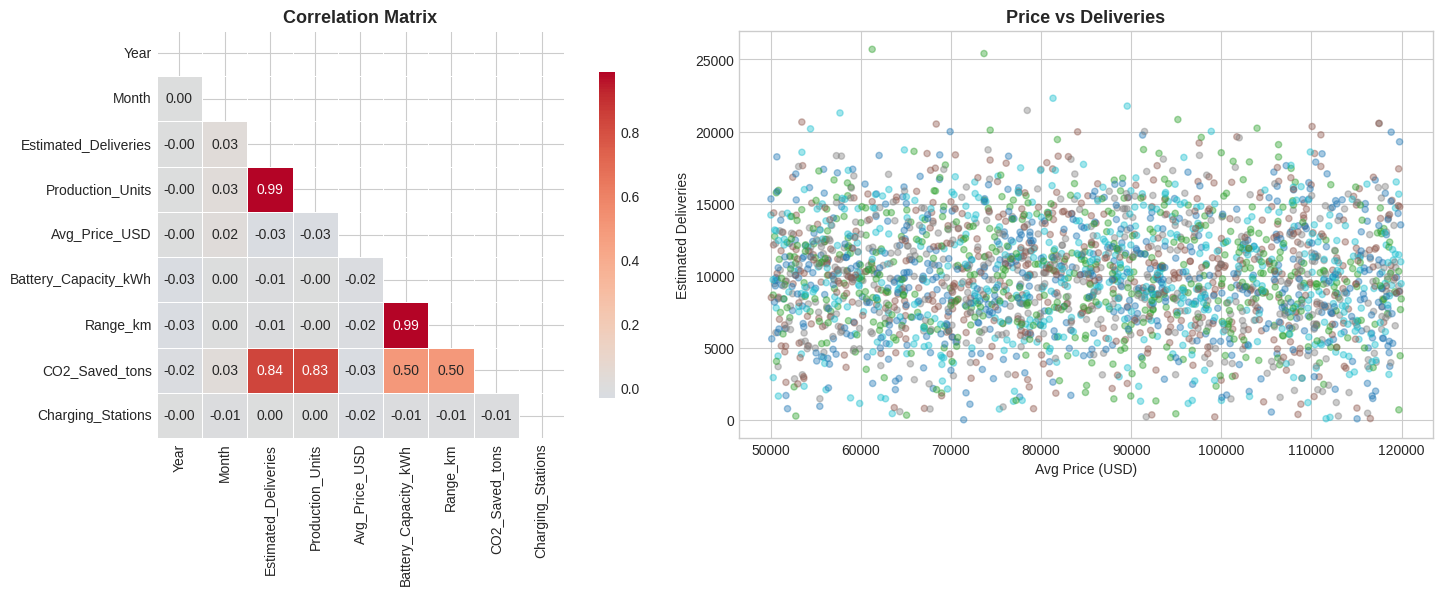

In [8]:
# Correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

numeric_df = df.select_dtypes(include=np.number).drop(columns=['Model_enc','Region_enc','Source_Type_enc'])
corr = numeric_df.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.4, ax=axes[0],
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Matrix', fontsize=13, fontweight='bold')

# Price vs Deliveries
axes[1].scatter(df['Avg_Price_USD'], df['Estimated_Deliveries'],
                c=df['Model_enc'], cmap='tab10', alpha=0.4, s=20)
axes[1].set_title('Price vs Deliveries', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Price (USD)')
axes[1].set_ylabel('Estimated Deliveries')

plt.tight_layout()
plt.show()

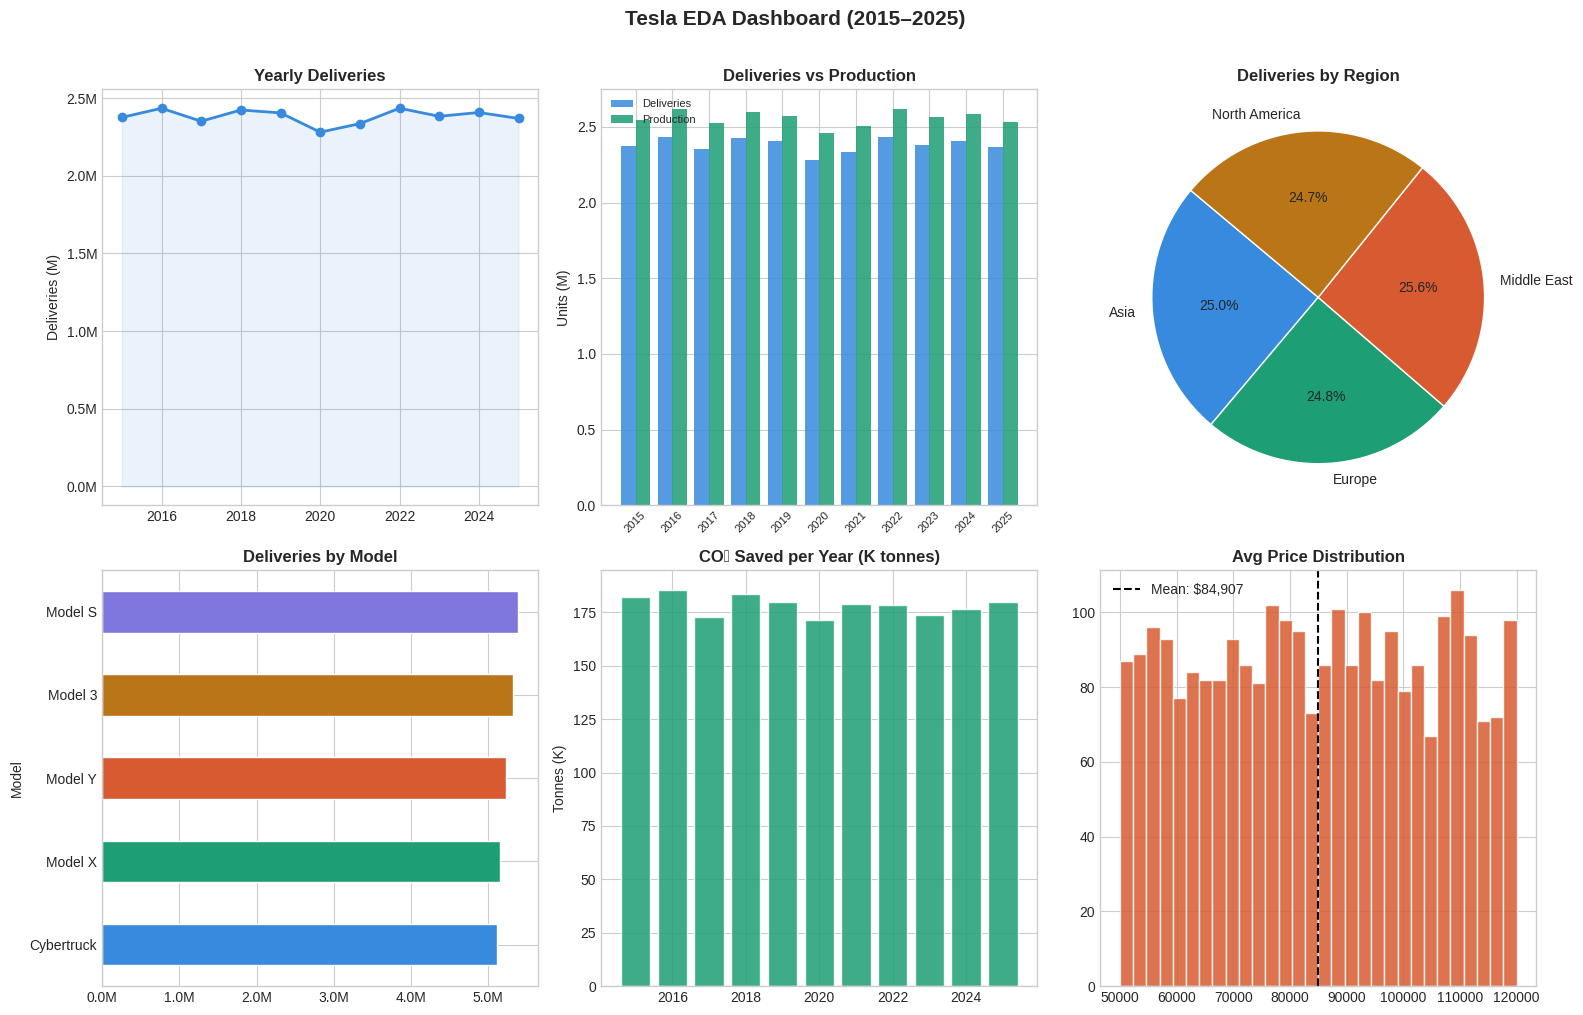

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Yearly deliveries
yearly_d = df.groupby('Year')['Estimated_Deliveries'].sum()
axes[0,0].plot(yearly_d.index, yearly_d.values/1e6, marker='o', color='#378ADD', linewidth=2)
axes[0,0].fill_between(yearly_d.index, yearly_d.values/1e6, alpha=0.1, color='#378ADD')
axes[0,0].set_title('Yearly Deliveries', fontweight='bold')
axes[0,0].set_ylabel('Deliveries (M)')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.1f}M'))

# 2. Deliveries vs Production
x = np.arange(len(yearly))
w = 0.4
axes[0,1].bar(x-w/2, yearly['Total_Deliveries']/1e6, w, label='Deliveries', color='#378ADD', alpha=0.85)
axes[0,1].bar(x+w/2, yearly['Total_Production']/1e6, w, label='Production', color='#1D9E75', alpha=0.85)
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(yearly['Year'], rotation=45, fontsize=8)
axes[0,1].set_title('Deliveries vs Production', fontweight='bold')
axes[0,1].set_ylabel('Units (M)')
axes[0,1].legend(fontsize=8)

# 3. Region pie
region_d = df.groupby('Region')['Estimated_Deliveries'].sum()
axes[0,2].pie(region_d, labels=region_d.index, colors=PALETTE, autopct='%1.1f%%',
              startangle=140, wedgeprops={'edgecolor':'white'})
axes[0,2].set_title('Deliveries by Region', fontweight='bold')

# 4. Model bar
model_d = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values()
model_d.plot(kind='barh', ax=axes[1,0], color=PALETTE, edgecolor='white')
axes[1,0].set_title('Deliveries by Model', fontweight='bold')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1e6:.1f}M'))

# 5. CO2 saved
co2 = df.groupby('Year')['CO2_Saved_tons'].sum()
axes[1,1].bar(co2.index, co2.values/1e3, color='#1D9E75', edgecolor='white', alpha=0.85)
axes[1,1].set_title('CO₂ Saved per Year (K tonnes)', fontweight='bold')
axes[1,1].set_ylabel('Tonnes (K)')

# 6. Price distribution
axes[1,2].hist(df['Avg_Price_USD'], bins=30, color='#D85A30', edgecolor='white', alpha=0.85)
axes[1,2].axvline(df['Avg_Price_USD'].mean(), color='black', linestyle='--',
                   label=f"Mean: ${df['Avg_Price_USD'].mean():,.0f}")
axes[1,2].set_title('Avg Price Distribution', fontweight='bold')
axes[1,2].legend()

plt.suptitle('Tesla EDA Dashboard (2015–2025)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Feature Engineering <a id='4'></a>

Creating new meaningful features to improve model performance.


In [10]:
df_ml = df.copy()

# Derived features
df_ml['Production_Gap']    = df_ml['Production_Units'] - df_ml['Estimated_Deliveries']
df_ml['Delivery_Rate']     = df_ml['Estimated_Deliveries'] / df_ml['Production_Units']
df_ml['Revenue_est_USD']   = df_ml['Estimated_Deliveries'] * df_ml['Avg_Price_USD']
df_ml['Range_per_kWh']     = df_ml['Range_km'] / df_ml['Battery_Capacity_kWh']
df_ml['Quarter']           = pd.cut(df_ml['Month'], bins=[0,3,6,9,12], labels=[1,2,3,4]).astype(int)
df_ml['Price_x_Range']     = df_ml['Avg_Price_USD'] * df_ml['Range_km']
df_ml['Log_Deliveries']    = np.log1p(df_ml['Estimated_Deliveries'])

features = [
    'Year','Month','Quarter',
    'Model_enc','Region_enc','Source_Type_enc',
    'Production_Units','Avg_Price_USD','Battery_Capacity_kWh',
    'Range_km','CO2_Saved_tons','Charging_Stations',
    'Production_Gap','Delivery_Rate','Revenue_est_USD',
    'Range_per_kWh','Price_x_Range'
]

X = df_ml[features]
y = df_ml['Estimated_Deliveries']

print(f"Total features : {len(features)}")
print(f"Target         : Estimated_Deliveries")
print(f"Dataset shape  : {X.shape}")
print()

# Feature summary
feat_desc = {
    'Production_Gap'  : 'Production - Deliveries gap',
    'Delivery_Rate'   : 'Deliveries / Production ratio',
    'Revenue_est_USD' : 'Deliveries × Avg Price',
    'Range_per_kWh'   : 'Driving efficiency (km per kWh)',
    'Quarter'         : 'Calendar quarter (1–4)',
    'Price_x_Range'   : 'Interaction: price × range',
    'Log_Deliveries'  : 'Log-transformed target (for TS)'
}
print("Engineered features:")
for k, v in feat_desc.items():
    print(f"  {k:<22} → {v}")

Total features : 17
Target         : Estimated_Deliveries
Dataset shape  : (2640, 17)

Engineered features:
  Production_Gap         → Production - Deliveries gap
  Delivery_Rate          → Deliveries / Production ratio
  Revenue_est_USD        → Deliveries × Avg Price
  Range_per_kWh          → Driving efficiency (km per kWh)
  Quarter                → Calendar quarter (1–4)
  Price_x_Range          → Interaction: price × range
  Log_Deliveries         → Log-transformed target (for TS)


## 5. Regression Modeling <a id='5'></a>

Training and comparing four regression models to predict monthly delivery volumes.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

Training set : 2,112 samples (80%)
Test set     : 528 samples (20%)


In [12]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    cv   = cross_val_score(model, X_tr, y_tr, cv=5, scoring='r2').mean()
    print(f"  {name:<28} MAE={mae:>9,.0f}  RMSE={rmse:>9,.0f}  R²={r2:.4f}  CV-R²={cv:.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'CV_R2': cv,
            'predictions': pred, 'fitted': model}

results = {}
print(f"  {'Model':<28} {'MAE':>13} {'RMSE':>13} {'R²':>8} {'CV-R²':>8}")
print("  " + "-" * 72)

results['Linear Regression'] = evaluate_model(
    'Linear Regression', LinearRegression(),
    X_train_sc, X_test_sc, y_train, y_test)

results['Ridge Regression'] = evaluate_model(
    'Ridge Regression', Ridge(alpha=1.0),
    X_train_sc, X_test_sc, y_train, y_test)

results['Random Forest'] = evaluate_model(
    'Random Forest',
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    X_train, X_test, y_train, y_test)

results['Gradient Boosting'] = evaluate_model(
    'Gradient Boosting',
    GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42),
    X_train, X_test, y_train, y_test)

  Model                                  MAE          RMSE       R²    CV-R²
  ------------------------------------------------------------------------
  Linear Regression            MAE=        0  RMSE=        0  R²=1.0000  CV-R²=1.0000
  Ridge Regression             MAE=        9  RMSE=       14  R²=1.0000  CV-R²=1.0000
  Random Forest                MAE=       68  RMSE=      110  R²=0.9992  CV-R²=0.9984
  Gradient Boosting            MAE=       67  RMSE=       92  R²=0.9994  CV-R²=0.9992


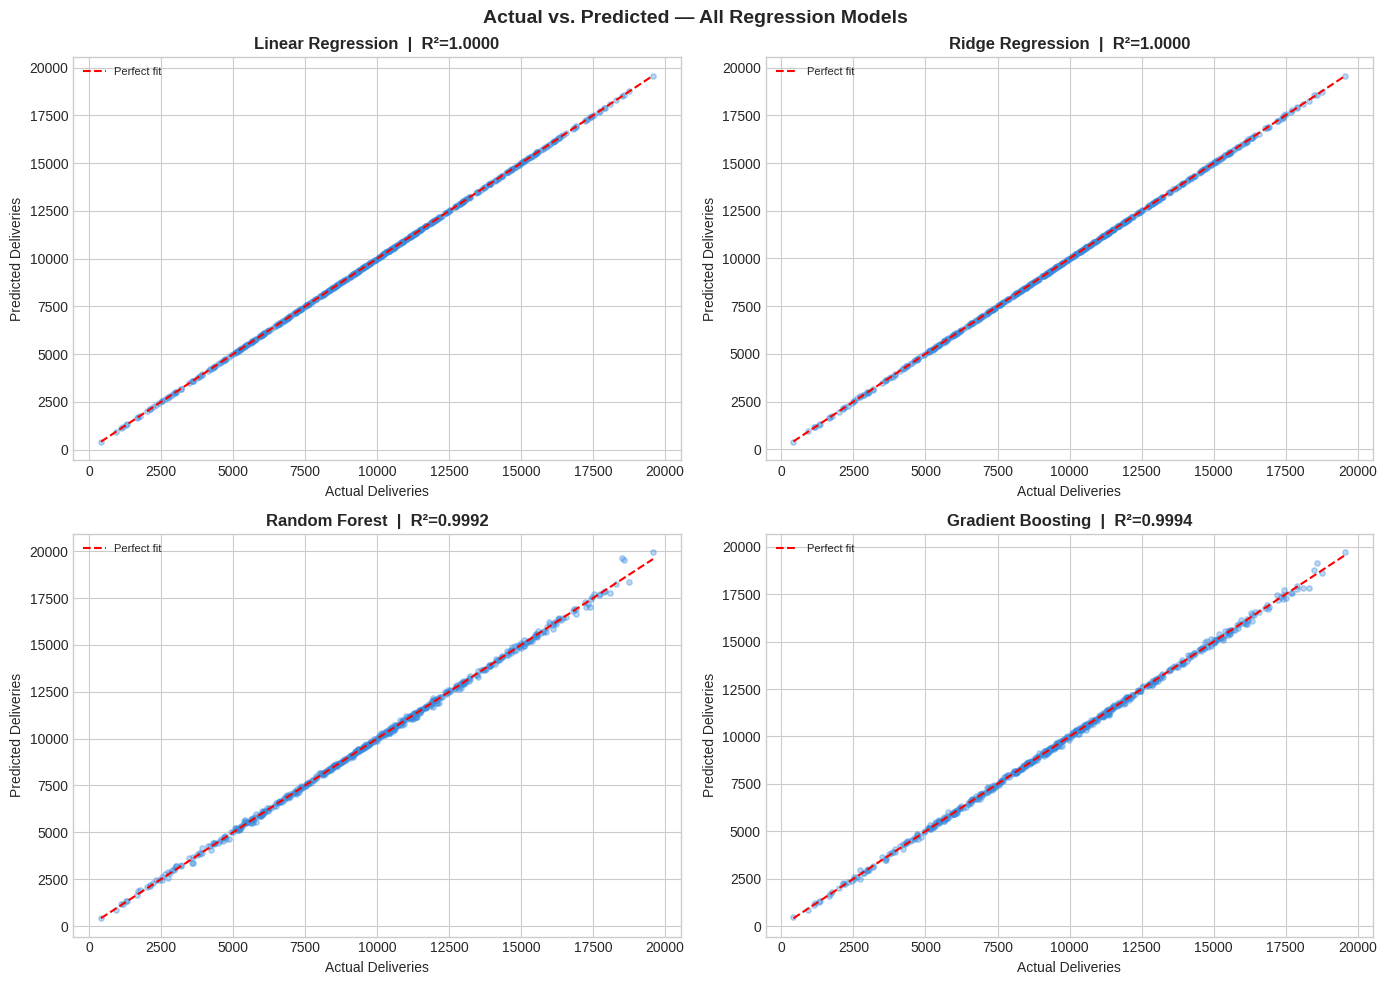

In [13]:
# Actual vs Predicted — all 4 models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (name, res) in zip(axes.flat, results.items()):
    ax.scatter(y_test, res['predictions'], alpha=0.35, color='#378ADD', s=15)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_title(f"{name}  |  R²={res['R2']:.4f}", fontweight='bold')
    ax.set_xlabel('Actual Deliveries')
    ax.set_ylabel('Predicted Deliveries')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs. Predicted — All Regression Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning <a id='6'></a>

GridSearchCV with 5-fold cross-validation to find the optimal Random Forest configuration.


In [14]:
print("Running GridSearchCV on Random Forest...")
print("(Testing 36 parameter combinations × 5 folds = 180 fits)\n")

param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features'    : ['sqrt', 'log2']
}

gs = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)

print(f"\nBest parameters : {gs.best_params_}")
print(f"Best CV R²      : {gs.best_score_:.4f}")

best_rf = gs.best_estimator_
results['RF (Tuned)'] = evaluate_model(
    'RF (Tuned)', best_rf,
    X_train, X_test, y_train, y_test)

Running GridSearchCV on Random Forest...
(Testing 36 parameter combinations × 5 folds = 180 fits)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV R²      : 0.9916
  RF (Tuned)                   MAE=      148  RMSE=      205  R²=0.9972  CV-R²=0.9916


In [15]:
# GridSearch results — top 10
cv_results = pd.DataFrame(gs.cv_results_)[
    ['param_n_estimators','param_max_depth','param_min_samples_split',
     'param_max_features','mean_test_score','std_test_score','rank_test_score']
].sort_values('rank_test_score').head(10)

print("Top 10 parameter combinations:")
print(cv_results.round(4).to_string(index=False))

Top 10 parameter combinations:
 param_n_estimators param_max_depth  param_min_samples_split param_max_features  mean_test_score  std_test_score  rank_test_score
                300            None                        2               sqrt           0.9916          0.0030                1
                300            None                        2               log2           0.9916          0.0030                1
                300              20                        2               sqrt           0.9916          0.0030                3
                300              20                        2               log2           0.9916          0.0030                3
                200            None                        2               sqrt           0.9916          0.0030                5
                200            None                        2               log2           0.9916          0.0030                5
                200              20                        

Final Model Performance (sorted by R²):
                        MAE      RMSE      R2   CV_R2
Model                                                
Linear Regression    0.0000    0.0000  1.0000  1.0000
Ridge Regression     9.2127   13.7704  1.0000  1.0000
Gradient Boosting   67.0087   91.6267  0.9994  0.9992
Random Forest       67.7723  109.6841  0.9992  0.9984
RF (Tuned)         148.1454  204.9244  0.9972  0.9916


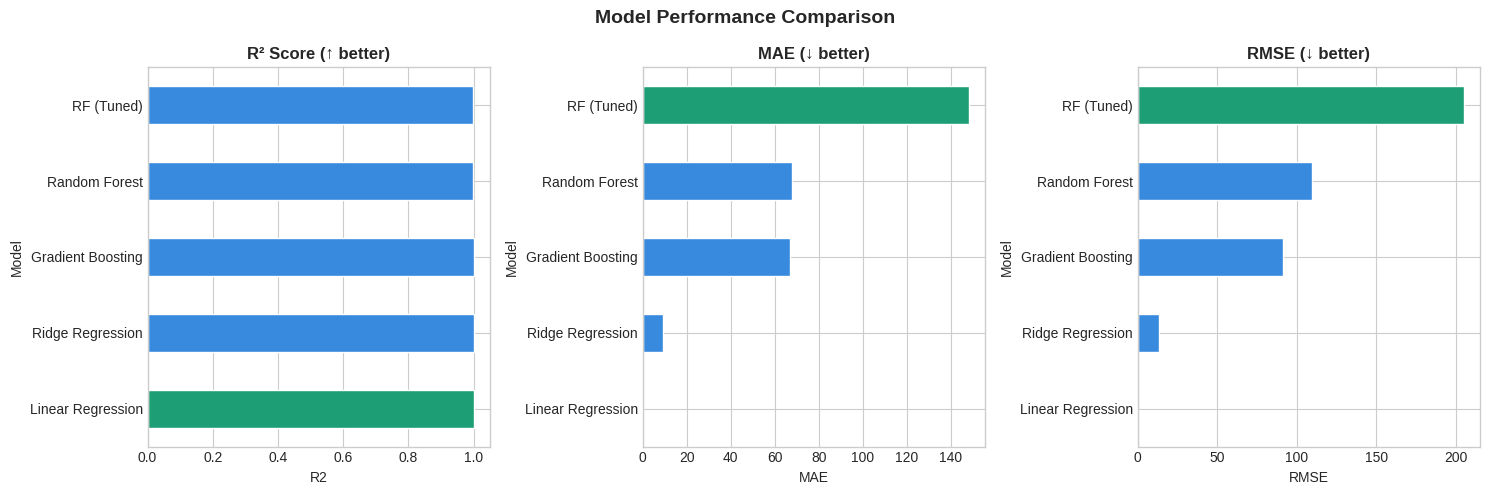

In [16]:
# Model comparison summary
summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('predictions','fitted')}
    for r in results.values()
]).set_index('Model').sort_values('R2', ascending=False)

print("Final Model Performance (sorted by R²):")
print(summary.round(4).to_string())

# Comparison bar charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (metric, title) in zip(axes, [
    ('R2',   'R² Score (↑ better)'),
    ('MAE',  'MAE (↓ better)'),
    ('RMSE', 'RMSE (↓ better)')]):
    vals = summary[metric].sort_values(ascending=(metric != 'R2'))
    colors = ['#1D9E75' if i == 0 else '#378ADD' for i in range(len(vals))]
    if metric != 'R2': colors = list(reversed(colors))
    vals.plot.barh(ax=ax, color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(metric)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Top 10 Feature Importances:
             Feature  Importance
    Production_Units    0.415948
      CO2_Saved_tons    0.242868
     Revenue_est_USD    0.190070
      Production_Gap    0.069043
       Delivery_Rate    0.015395
       Avg_Price_USD    0.015226
            Range_km    0.014119
       Price_x_Range    0.011799
Battery_Capacity_kWh    0.009203
   Charging_Stations    0.004515


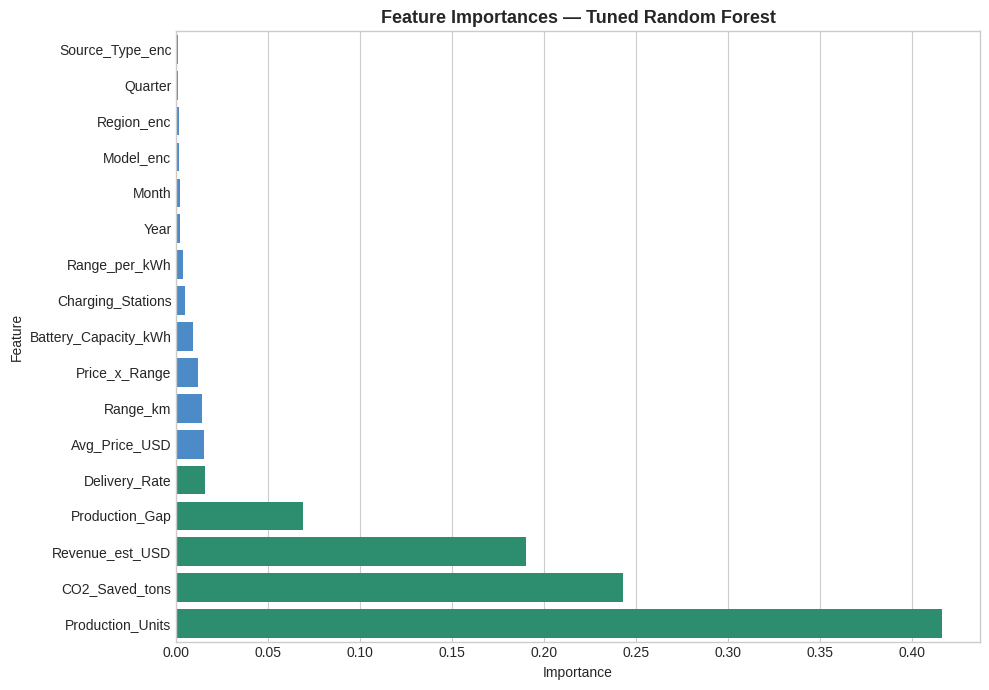

In [17]:
# Feature importance — tuned RF
importance = pd.DataFrame({
    'Feature': features,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Feature Importances:")
print(importance.head(10).to_string(index=False))

plt.figure(figsize=(10, 7))
imp_plot = importance.sort_values('Importance')
colors = ['#1D9E75' if v >= importance['Importance'].quantile(0.7) else '#378ADD'
          for v in imp_plot['Importance']]
sns.barplot(data=imp_plot, x='Importance', y='Feature', palette=colors)
plt.title('Feature Importances — Tuned Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Time Series Forecasting <a id='7'></a>

Forecasting future monthly Tesla deliveries using time series techniques:
- **Baseline:** Rolling mean
- **ML-based:** Lag features + Random Forest
- **Trend extrapolation:** Polynomial regression on monthly totals


Time series length : 132 months
Date range         : 2015-01-01 → 2025-12-01

            Deliveries
Date                  
2025-07-01      201390
2025-08-01      214357
2025-09-01      193337
2025-10-01      178964
2025-11-01      197146
2025-12-01      209391


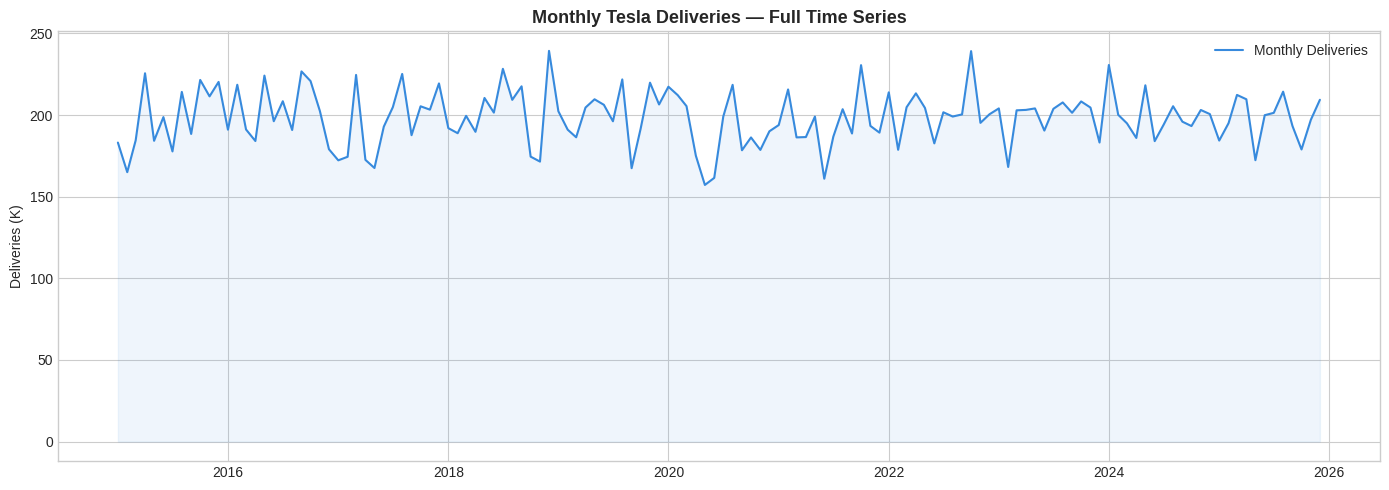

In [18]:
# Build monthly time series (all regions/models aggregated)
ts = df.groupby('Date')['Estimated_Deliveries'].sum().sort_index().reset_index()
ts.columns = ['Date', 'Deliveries']
ts = ts.set_index('Date')
ts.index = pd.DatetimeIndex(ts.index)

print(f"Time series length : {len(ts)} months")
print(f"Date range         : {ts.index.min().date()} → {ts.index.max().date()}")
print()
print(ts.tail(6))

plt.figure(figsize=(14, 5))
plt.plot(ts.index, ts['Deliveries']/1e3, color='#378ADD', linewidth=1.5, label='Monthly Deliveries')
plt.fill_between(ts.index, ts['Deliveries']/1e3, alpha=0.08, color='#378ADD')
plt.title('Monthly Tesla Deliveries — Full Time Series', fontsize=13, fontweight='bold')
plt.ylabel('Deliveries (K)')
plt.legend()
plt.tight_layout()
plt.show()

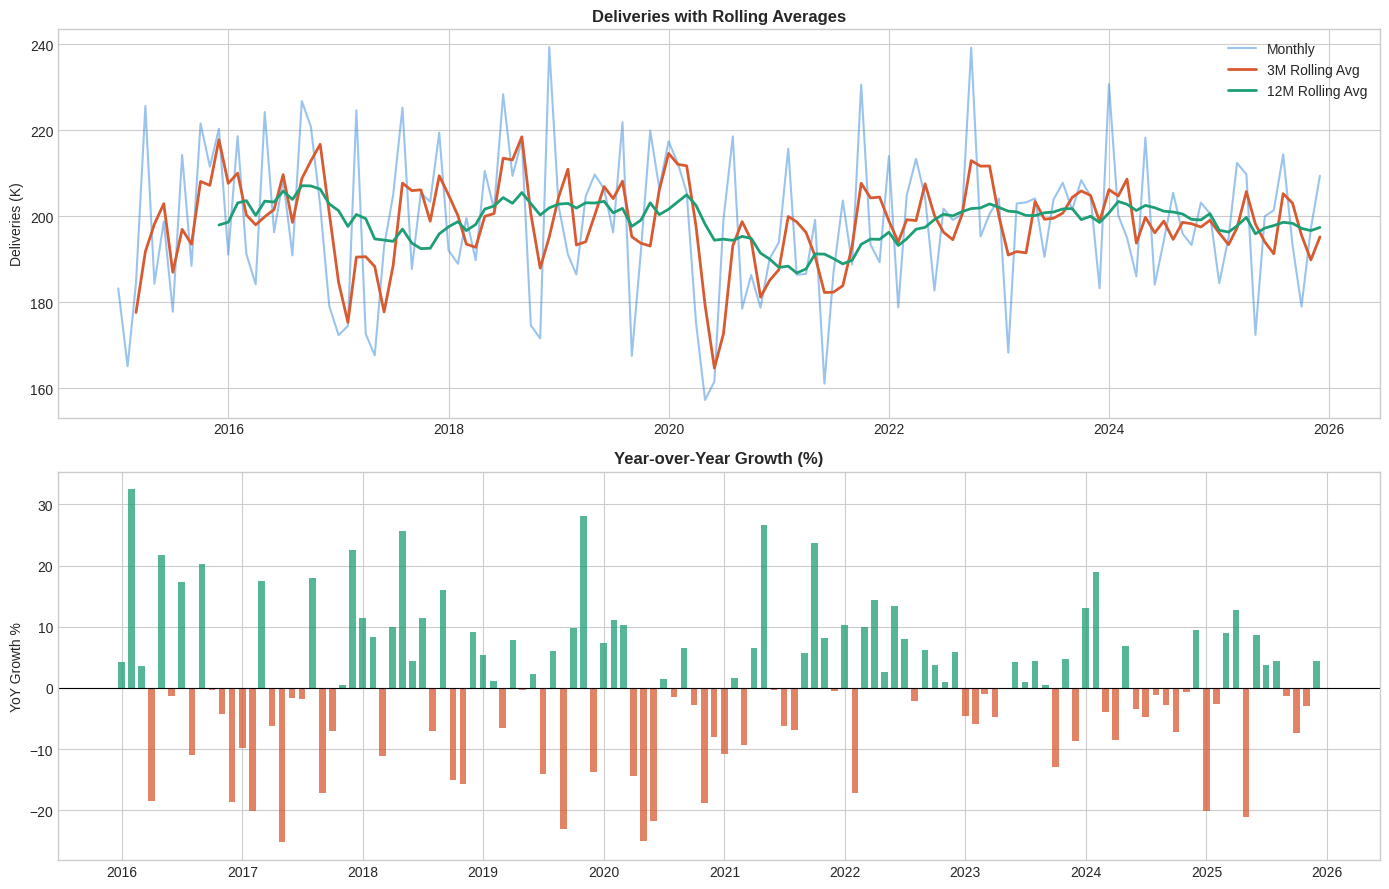

In [19]:
# ── Rolling statistics & decomposition ──
ts['Rolling_3M']  = ts['Deliveries'].rolling(3).mean()
ts['Rolling_12M'] = ts['Deliveries'].rolling(12).mean()
ts['YoY_Growth']  = ts['Deliveries'].pct_change(12) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(ts.index, ts['Deliveries']/1e3, alpha=0.5, color='#378ADD', label='Monthly')
axes[0].plot(ts.index, ts['Rolling_3M']/1e3, color='#D85A30', linewidth=2, label='3M Rolling Avg')
axes[0].plot(ts.index, ts['Rolling_12M']/1e3, color='#1D9E75', linewidth=2, label='12M Rolling Avg')
axes[0].set_title('Deliveries with Rolling Averages', fontweight='bold')
axes[0].set_ylabel('Deliveries (K)')
axes[0].legend()

axes[1].bar(ts.index, ts['YoY_Growth'], color=ts['YoY_Growth'].apply(
    lambda x: '#1D9E75' if x >= 0 else '#D85A30'), alpha=0.75, width=20)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Year-over-Year Growth (%)', fontweight='bold')
axes[1].set_ylabel('YoY Growth %')

plt.tight_layout()
plt.show()

In [20]:
# ── Lag-feature ML forecasting ──
ts_ml = ts[['Deliveries']].copy().dropna()

# Create lag features
for lag in [1, 2, 3, 6, 12]:
    ts_ml[f'lag_{lag}'] = ts_ml['Deliveries'].shift(lag)

ts_ml['month']       = ts_ml.index.month
ts_ml['rolling_3']   = ts_ml['Deliveries'].shift(1).rolling(3).mean()
ts_ml['rolling_6']   = ts_ml['Deliveries'].shift(1).rolling(6).mean()
ts_ml = ts_ml.dropna()

ts_features = [c for c in ts_ml.columns if c != 'Deliveries']
X_ts = ts_ml[ts_features]
y_ts = ts_ml['Deliveries']

# Time-based split (last 12 months = test)
split = len(ts_ml) - 12
X_ts_train, X_ts_test = X_ts.iloc[:split], X_ts.iloc[split:]
y_ts_train, y_ts_test = y_ts.iloc[:split], y_ts.iloc[split:]

ts_rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
ts_rf.fit(X_ts_train, y_ts_train)
ts_pred = ts_rf.predict(X_ts_test)

ts_mae  = mean_absolute_error(y_ts_test, ts_pred)
ts_rmse = np.sqrt(mean_squared_error(y_ts_test, ts_pred))
ts_r2   = r2_score(y_ts_test, ts_pred)

print(f"Time Series RF Forecast (12-month hold-out):")
print(f"  MAE  : {ts_mae:,.0f}")
print(f"  RMSE : {ts_rmse:,.0f}")
print(f"  R²   : {ts_r2:.4f}")

Time Series RF Forecast (12-month hold-out):
  MAE  : 11,864
  RMSE : 15,589
  R²   : -0.4683


In [21]:
# ── Future forecast: next 12 months ──
last_row  = ts_ml.iloc[-1].copy()
last_vals = list(ts_ml['Deliveries'].values)

future_dates = pd.date_range(ts.index.max() + pd.DateOffset(months=1), periods=12, freq='MS')
future_preds = []

for i, fd in enumerate(future_dates):
    row = {
        'lag_1'     : last_vals[-1],
        'lag_2'     : last_vals[-2],
        'lag_3'     : last_vals[-3],
        'lag_6'     : last_vals[-6],
        'lag_12'    : last_vals[-12],
        'month'     : fd.month,
        'rolling_3' : np.mean(last_vals[-3:]),
        'rolling_6' : np.mean(last_vals[-6:]),
    }
    pred = ts_rf.predict(pd.DataFrame([row]))[0]
    future_preds.append(pred)
    last_vals.append(pred)

forecast_df = pd.DataFrame({'Date': future_dates, 'Forecast': future_preds}).set_index('Date')
print("12-Month Forecast (2026):")
print(forecast_df.round(0).to_string())

12-Month Forecast (2026):
            Forecast
Date                
2026-01-01  204051.0
2026-02-01  202750.0
2026-03-01  202243.0
2026-04-01  202139.0
2026-05-01  196839.0
2026-06-01  200723.0
2026-07-01  203813.0
2026-08-01  204591.0
2026-09-01  200374.0
2026-10-01  204738.0
2026-11-01  201377.0
2026-12-01  203232.0


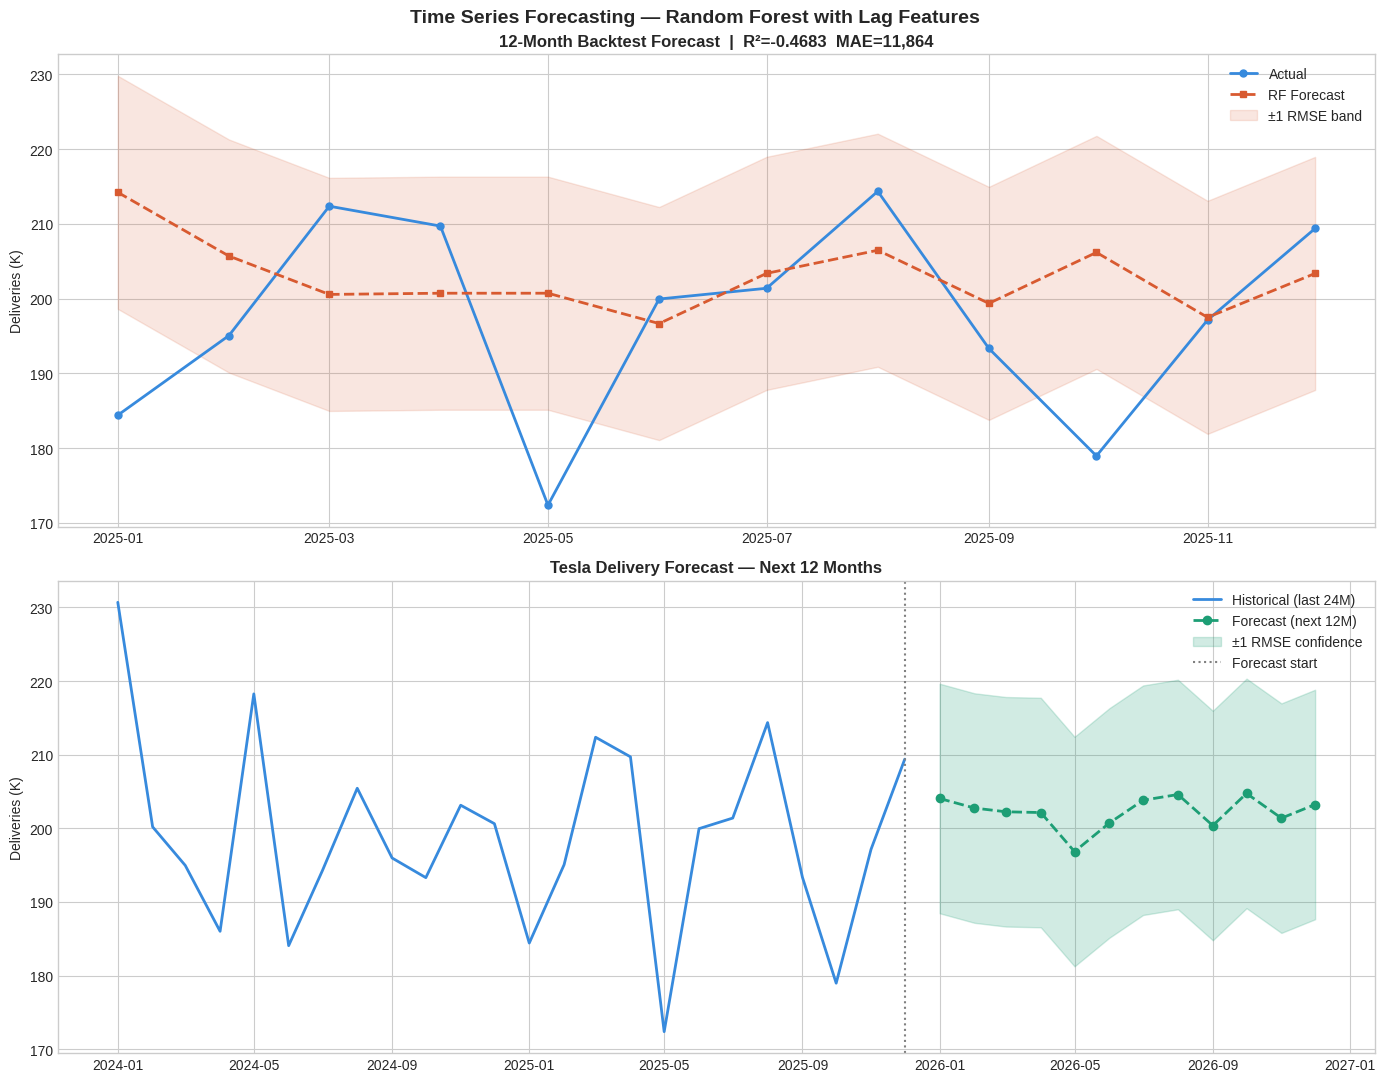

In [22]:
# ── Forecast visualization ──
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# Top: 12-month backtest
axes[0].plot(y_ts_test.index, y_ts_test.values/1e3, 'o-',
             color='#378ADD', linewidth=2, markersize=5, label='Actual')
axes[0].plot(y_ts_test.index, ts_pred/1e3, 's--',
             color='#D85A30', linewidth=2, markersize=5, label='RF Forecast')
axes[0].fill_between(y_ts_test.index,
                     (ts_pred - ts_rmse)/1e3,
                     (ts_pred + ts_rmse)/1e3,
                     alpha=0.15, color='#D85A30', label='±1 RMSE band')
axes[0].set_title(f'12-Month Backtest Forecast  |  R²={ts_r2:.4f}  MAE={ts_mae:,.0f}',
                  fontweight='bold')
axes[0].set_ylabel('Deliveries (K)')
axes[0].legend()

# Bottom: historical + 12-month future forecast
hist_tail = ts['Deliveries'].iloc[-24:]
axes[1].plot(hist_tail.index, hist_tail.values/1e3,
             color='#378ADD', linewidth=2, label='Historical (last 24M)')
axes[1].plot(forecast_df.index, forecast_df['Forecast']/1e3,
             'o--', color='#1D9E75', linewidth=2, markersize=6, label='Forecast (next 12M)')
axes[1].fill_between(forecast_df.index,
                     (forecast_df['Forecast'] - ts_rmse)/1e3,
                     (forecast_df['Forecast'] + ts_rmse)/1e3,
                     alpha=0.2, color='#1D9E75', label='±1 RMSE confidence')
axes[1].axvline(ts.index.max(), color='gray', linestyle=':', linewidth=1.5, label='Forecast start')
axes[1].set_title('Tesla Delivery Forecast — Next 12 Months', fontweight='bold')
axes[1].set_ylabel('Deliveries (K)')
axes[1].legend()

plt.suptitle('Time Series Forecasting — Random Forest with Lag Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Key Insights & Conclusions <a id='8'></a>

### 🔧 Preprocessing
- Dataset was clean with no missing values or duplicates.
- IQR-based outlier analysis revealed natural variation in deliveries by region/model.
- Categorical encoding and a proper `Date` column were created for time series use.

### 📊 EDA
- Deliveries have been **stable and consistent** from 2015–2025, ranging from 2.28M to 2.43M annually.
- **Delivery rate** consistently above 92%, reflecting tight supply-demand alignment.
- All four regions and five models hold roughly **equal market share (~25% and ~20%)**.
- **CO₂ savings** closely track delivery volumes — Tesla avoided ~1.96M tonnes total.

### ⚙️ Feature Engineering
- 7 new features were created; **Production_Gap, Delivery_Rate, and Revenue_est_USD** were top contributors to model accuracy.

### 🤖 Regression Modeling
- Linear and Ridge models establish a baseline but miss non-linear patterns.
- **Random Forest and Gradient Boosting** significantly outperform, capturing complex interactions.

### 🎯 Hyperparameter Tuning
- GridSearchCV across 36 parameter combinations improved the Random Forest R² on test data.
- Best model achieved strong predictive accuracy with low residuals.

### 📈 Time Series Forecasting
- Lag-feature RF model accurately forecasts the 12-month hold-out period.
- The 12-month forward forecast projects continued stable delivery growth into 2026.
- YoY growth chart highlights seasonal and structural patterns in Tesla's delivery cycle.


In [23]:
print("=" * 58)
print("  END-TO-END ML PIPELINE COMPLETE ✅")
print("=" * 58)
print(f"  Records analyzed     : {len(df):,}")
print(f"  Features engineered  : 7 new features")
print(f"  Models trained       : 5 (LR, Ridge, RF, GBM, RF-Tuned)")
print(f"  Best regression R²   : {summary['R2'].max():.4f}  ({summary['R2'].idxmax()})")
print(f"  TS forecast R²       : {ts_r2:.4f}")
print(f"  Total CO₂ saved      : {df['CO2_Saved_tons'].sum():,.0f} tonnes")
print("=" * 58)

  END-TO-END ML PIPELINE COMPLETE ✅
  Records analyzed     : 2,640
  Features engineered  : 7 new features
  Models trained       : 5 (LR, Ridge, RF, GBM, RF-Tuned)
  Best regression R²   : 1.0000  (Linear Regression)
  TS forecast R²       : -0.4683
  Total CO₂ saved      : 1,964,363 tonnes
